# Credit Card Fraud Detection using Machine Learning

## Objective
Detect fraudulent credit card transactions using ML models.

## Problem Type
Binary Classification

## Technologies Used
- Python
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- SMOTE

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [143]:
# Loading the dataset
# into a Pandas DataFrame

In [89]:
credit_card_data =pd.read_csv('/content/creditcard_1stProject.csv')

In [144]:
# Understanding dataset structure
# and basic information

In [90]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [91]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
27814,34711,1.443955,-1.052462,-0.141721,-1.564017,-0.966274,-0.333886,-0.777060,0.023616,-2.168826,...,-0.479940,-1.165220,0.155226,-0.409701,0.179672,-0.446258,0.004329,0.000060,32.39,0.0
27815,34711,-0.263364,0.931818,1.193111,-0.507924,0.862019,0.249381,0.815449,-0.090801,-0.520583,...,-0.310112,-0.648621,-0.253746,-1.030111,-0.046091,0.107328,0.101296,-0.124600,1.49,0.0
27816,34712,0.976345,-1.024867,0.978714,0.639442,-1.413711,0.311635,-0.909035,0.232423,-0.493025,...,-0.279978,-0.599463,-0.081403,-0.059427,0.202311,-0.405753,0.055109,0.052975,151.00,0.0
27817,34712,1.464604,-0.437919,-0.018869,-1.057177,-0.154243,0.251215,-0.584866,-0.025483,-0.841369,...,-0.148384,-0.454571,-0.019732,-1.313689,0.379650,-0.368497,0.031746,0.007238,8.00,0.0
27818,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27819 entries, 0 to 27818
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    27819 non-null  int64  
 1   V1      27818 non-null  float64
 2   V2      27818 non-null  float64
 3   V3      27818 non-null  float64
 4   V4      27818 non-null  float64
 5   V5      27818 non-null  float64
 6   V6      27818 non-null  float64
 7   V7      27818 non-null  float64
 8   V8      27818 non-null  float64
 9   V9      27818 non-null  float64
 10  V10     27818 non-null  float64
 11  V11     27818 non-null  float64
 12  V12     27818 non-null  float64
 13  V13     27818 non-null  float64
 14  V14     27818 non-null  float64
 15  V15     27818 non-null  float64
 16  V16     27818 non-null  float64
 17  V17     27818 non-null  float64
 18  V18     27818 non-null  float64
 19  V19     27818 non-null  float64
 20  V20     27818 non-null  float64
 21  V21     27818 non-null  float64
 22

In [145]:
# Checking for missing values
# and duplicate records
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [146]:
#distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

,count
Class,
0.0,27725
1.0,93


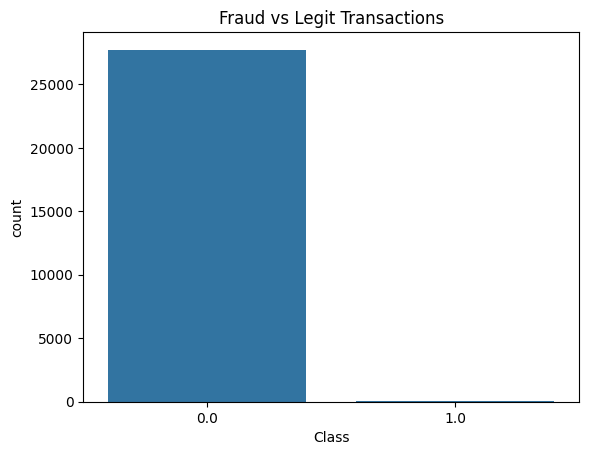

In [95]:
sns.countplot(x='Class', data=credit_card_data)
plt.title("Fraud vs Legit Transactions")
plt.show()

In [96]:
#separating the data for analysis
legit=credit_card_data[credit_card_data.Class==0]
fraud=credit_card_data[credit_card_data.Class==1]

In [97]:
print(legit.shape)
print(fraud.shape)

(27725, 31)
(93, 31)


In [98]:
legit.Amount.describe()

,Amount
count,27725.000000
mean,77.232517
std,219.509762
min,0.000000
25%,6.490000
50%,19.950000
75%,69.320000
max,7879.420000


In [99]:
fraud.Amount.describe()

,Amount
count,93.000000
mean,96.609677
std,259.128010
min,0.000000
25%,1.000000
50%,1.100000
75%,99.990000
max,1809.680000


In [100]:
 #compare the values of legit and fraud
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,20440.754518,-0.190595,0.129284,0.765200,0.201632,-0.180681,0.092904,-0.099318,0.014884,0.405538,...,0.041673,-0.037007,-0.125822,-0.040202,0.011510,0.129192,0.022983,0.010650,0.003732,77.232517
1.0,18829.451613,-8.165086,6.134379,-11.690379,6.070066,-5.753486,-2.388962,-7.986805,4.121062,-2.922478,...,0.697894,0.549621,-0.372248,-0.340859,-0.260055,0.359772,0.179521,0.832824,0.100500,96.609677


In [101]:
# separating the data and labels
credit_card_data = credit_card_data.dropna()
X = credit_card_data.drop(columns='Class', axis=1)
Y = credit_card_data['Class']

In [102]:
X.shape

(27818, 30)

In [103]:
Y.shape


(27818,)

In [104]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=2
)

SMOTE Approach

In [147]:
# Applying SMOTE to handle
# class imbalance in training data
smote=SMOTE(random_state=42)
features,target=smote.fit_resample(X_train,Y_train)

In [148]:
# Standardizing feature values
# using StandardScaler
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [107]:
print(features)

[[-0.11528504  0.67558763 -0.60236495 ... -0.52131492 -0.12808435
  -0.40935983]
 [ 0.05155247  0.69777131 -0.85374441 ... -0.45998998 -0.1358295
  -0.30535733]
 [ 0.98702762  0.64852435 -0.78029945 ... -0.40053385 -0.12467709
  -0.05601132]
 ...
 [ 1.41717584  0.51650882 -0.20492002 ...  0.52532979  0.75732237
  -0.31067078]
 [ 1.34051576  0.32755242 -0.29437551 ...  0.58453189  0.90173443
   1.30612585]
 [-0.1559297  -0.22801278  0.01631598 ...  0.68409138 -0.85675517
  -0.39452667]]


In [108]:
print(target)

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
44355    1.0
44356    1.0
44357    1.0
44358    1.0
44359    1.0
Name: Class, Length: 44360, dtype: float64


In [109]:
features_train,features_test,target_train,target_test=train_test_split(features,target,test_size=0.2,stratify=target, random_state=42)

In [110]:
print(features.shape,features_train.shape,features_test.shape)

(44360, 30) (35488, 30) (8872, 30)


**Model Training**

Logistic Regression

In [111]:
model=LogisticRegression()

In [112]:
#training logistic Regression Model with Traning Data
model.fit(features_train,target_train)

LogisticRegression()

Model Evaluation


Confusion Matrix (training data)

In [113]:

features_train_prediction =model.predict(features_train)


In [114]:
confusion_matrix_train=confusion_matrix(target_train,features_train_prediction)

In [115]:
print(confusion_matrix_train)

[[17651    93]
 [  239 17505]]


Confusion Matrix (testing data)

In [116]:
features_test_prediction=model.predict(features_test)

In [117]:
confusion_matrix_test=confusion_matrix(target_test,features_test_prediction)

In [118]:
print(confusion_matrix_test)

[[4411   25]
 [  68 4368]]


Accuracy Score

In [119]:
# accuracy on training data
training_data_accuracy = accuracy_score(target_train,features_train_prediction)

In [120]:
print('Accuracy on Training data : ',training_data_accuracy)

Accuracy on Training data :  0.9906447249774571


In [121]:

testing_data_accuracy=accuracy_score(target_test,features_test_prediction)

In [122]:
print('Accuracy on Testing data : ',testing_data_accuracy)

Accuracy on Testing data :  0.9895175834084761


Precision score

In [123]:
training_data_precision = precision_score(target_train,features_train_prediction)

In [124]:
print('precision on Training data : ',training_data_precision )

precision on Training data :  0.9947153085577907


In [125]:

testing_data_precision=precision_score(target_test,features_test_prediction)

In [126]:
print('precision on Testing data : ',testing_data_precision)

precision on Testing data :  0.9943091281584339


Recall score

In [127]:
training_data_recall = recall_score(target_train,features_train_prediction)

In [128]:
print('Recall on Training data : ',training_data_recall )

Recall on Training data :  0.9865306582506763


In [129]:
testing_data_recall=recall_score(target_test,features_test_prediction)

In [130]:
print('Recall on Testing data : ',testing_data_recall)

Recall on Testing data :  0.9846708746618575


F1 Score

In [131]:
training_data_F1_score = f1_score(target_train,features_train_prediction)

In [132]:
print('F1 Score on Training data : ',training_data_F1_score )

F1 Score on Training data :  0.990606077754513


In [133]:
testing_data_F1_score=f1_score(target_test,features_test_prediction)

In [134]:
print('F1 Score on Testing data : ',testing_data_F1_score)

F1 Score on Testing data :  0.9894665307509344


Classification Report(training data)

In [135]:
classification_report_training=classification_report(target_train,features_train_prediction)

In [136]:
print(classification_report_training)

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     17744
         1.0       0.99      0.99      0.99     17744

    accuracy                           0.99     35488
   macro avg       0.99      0.99      0.99     35488
weighted avg       0.99      0.99      0.99     35488



Classification Report(testing data)


In [137]:
classification_report_testing=classification_report(target_test,features_test_prediction)

In [138]:
print(classification_report_testing)

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      4436
         1.0       0.99      0.98      0.99      4436

    accuracy                           0.99      8872
   macro avg       0.99      0.99      0.99      8872
weighted avg       0.99      0.99      0.99      8872



ROC Curve

In [139]:
target_probs=model.predict_proba(features_test)[:,1]

In [140]:
fpr,tpr,thresholds = roc_curve(target_test,target_probs)

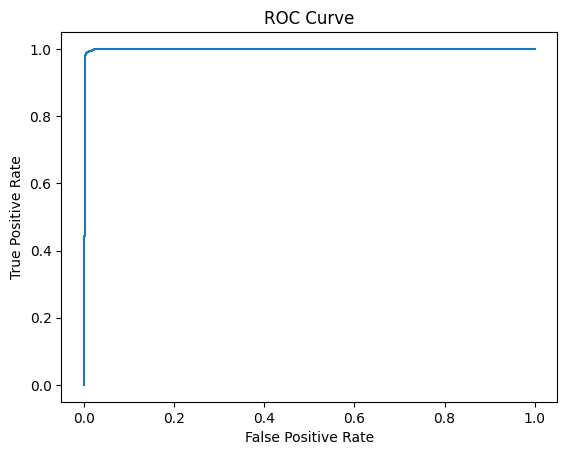

In [141]:
plt.plot(fpr,tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [142]:
roc_score = roc_auc_score(target_test, target_probs)

print("ROC-AUC Score :", roc_score)

ROC-AUC Score : 0.9985351733216465


In [149]:
# ======================================
# Project Conclusion
# ======================================
# The Logistic Regression model was
# successfully trained to detect
# fraudulent transactions.
#
# SMOTE was used to address
# class imbalance.
#
# The model achieved excellent
# classification performance
# on unseen test data.
#
# Future Improvements:
# 1. Random Forest
# 2. XGBoost
# 3. Hyperparameter Tuning
# 4. Model Deployment
# ======================================